
0: 384x640 None9.2ms
Speed: 1.8ms preprocess, 9.2ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)
[[     615.72      333.54      138.34      33.365     0.15249]
 [     765.92      172.93      130.42       37.54     0.15592]
 [     635.33      378.86       97.09      46.446     0.11002]
 [     766.19      172.54      132.12      36.651     0.14625]
 [     767.81      306.19      129.44      179.75    0.039287]]
8.933676


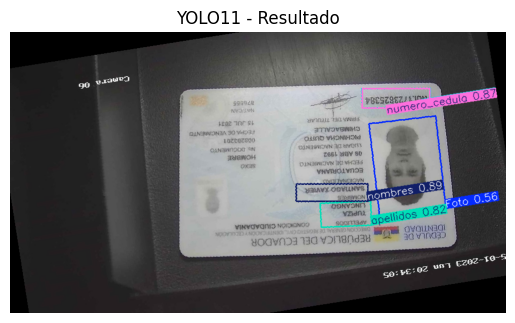

In [14]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np 
# Cargar el modelo YOLO (puede ser 'yolov8n.pt' o tu modelo personalizado)
#model = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best_v8n_obb.pt")  # Cambia por "runs/detect/train/weights/best.pt"
model = YOLO("/root/Trabajo/MiCasitaCIDetection/runs/obb/yolo11_obb_custom/weights/best.pt")  # Cambia por "runs/detect/train/weights/best.pt"

# Tipo de fuente
SOURCE_TYPE = "image"  # Opciones: "image"
#SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Cedula_Celeste/ImagenCedula_022rzNH.jpg"  # Ruta de la imagen
SOURCE_PATH = "/root/Trabajo/Cedulas/imagenes_cedula_peq/Cedula_Celeste/2c28a35d-ImagenCedula_1.jpg"  # Ruta de la imagen

if SOURCE_TYPE == "image":
    # Cargar imagen con PIL
    image = Image.open(SOURCE_PATH).convert("RGB").rotate(180)

    # Realizar inferencia
    results = model(image)

    # Mostrar resultados usando PIL
    for result in results:
        # result.plot() devuelve una imagen NumPy (BGR), la convertimos a RGB para PIL
        img_array = result.plot()[:, :, ::-1]
        data=result.obb.xywhr.cpu().numpy()
        print(data)
        print(np.degrees(data[1][-1]))
        result_image = Image.fromarray(img_array).rotate(np.degrees(data[1][-1]))
        # Mostrar usando matplotlib
        plt.imshow(result_image)
        plt.axis('off')
        plt.title("YOLO11 - Resultado")
        plt.show()


In [ ]:
! pip uninstall  torchvision -y 
! pip install  torchvision  --index-url https://download.pytorch.org/whl/cu128

In [ ]:
#import os
#import random
#from pathlib import Path
#import shutil
#
## Carpetas de origen
#IMAGES_DIR = Path("C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/images")
#LABELS_DIR = Path("C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/labels")
#
## Porcentajes de división
#train_ratio = 0.7
#val_ratio = 0.3
#test_ratio = 0.0
#
## Asegurarse de tener imágenes con su .txt correspondiente
#image_files = sorted([f for f in IMAGES_DIR.glob("*.*") if f.suffix in ['.jpg', '.jpeg', '.png']])
#valid_files = [f for f in image_files if (LABELS_DIR / f.with_suffix(".txt").name).exists()]
#
#print(f"Total de imágenes válidas: {len(valid_files)}")
#
## Mezclar aleatoriamente
#random.shuffle(valid_files)
#
## Separar
#n = len(valid_files)
#train_files = valid_files[:int(n * train_ratio)]
#val_files = valid_files[int(n * train_ratio):int(n * (train_ratio + val_ratio))]
#test_files = valid_files[int(n * (train_ratio + val_ratio)):]
#
#splits = {
#    "train": train_files,
#    "val": val_files,
#    "test": test_files,
#}
#
## Crear carpetas destino
#for split in splits:
#    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
#    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)
#
#    for img_path in splits[split]:
#        label_path = LABELS_DIR / img_path.with_suffix(".txt").name
#        shutil.copy(img_path, IMAGES_DIR / split / img_path.name)
#        shutil.copy(label_path, LABELS_DIR / split / label_path.name)
#
#print("✅ División completada: train / val / test.")


Total de imágenes válidas: 2470
✅ División completada: train / val / test.


In [3]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
#print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
! pip show torchvision

False
None
Name: torchvision
Version: 0.22.1
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: C:\Users\USER\.conda\envs\trabajo\Lib\site-packages
Requires: numpy, pillow, torch
Required-by: 


In [ ]:
#import os
#
## Carpetas de etiquetas
#label_dirs = ["C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/dataset/labels/train", "C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/dataset/labels/val"]
#
#for label_dir in label_dirs:
#    for file_name in os.listdir(label_dir):
#        if file_name.endswith(".txt"):
#            file_path = os.path.join(label_dir, file_name)
#
#            with open(file_path, "r") as f:
#                content = f.read()
#            # Reemplazos específicos de números seguidos por espacio
#            content = content.replace("6 ", "4 ")
#            content = content.replace("7 ", "5 ")
#
#            with open(file_path, "w") as f:
#                f.write(content)
#

In [16]:
from ultralytics import YOLO

# Cargar un modelo base (puedes cambiar a yolov8s.pt, yolov8m.pt, etc.)
model = YOLO(
    "yolo11n-obb.pt"
)  # o "yolov8s.pt", o "yolov8n.yaml" para comenzar desde cero

# Entrenar el modelo
model.train(
    data="/root/Trabajo/Training_Cedulas2.0 (2)/data.yaml",  # Ruta al archivo de configuración
    cfg="/root/Trabajo/Training_Cedulas2.0 (2)/augment.yaml",  # Ruta al archivo de configuración del modelo
    epochs=500,  # Número de épocas
    imgsz=640,  # Tamaño de entrada de imagen
    batch=64,  # Tamaño del batch
    workers=4,  # Núm. de workers para carga de datos
    device=0,  # Usa la GPU 0; usa "cpu" para CPU
    name="yolo11_obb_custom",  # Nombre de la carpeta del experimento
    verbose=True,
    patience=100,
    weight_decay=1e-4,
    
)

TypeError: 'augment={'degrees': 180, 'translate': 0.1, 'scale': 0.5, 'shear': 0, 'fliplr': 0.5, 'flipud': 0.0, 'perspective': 0.0, 'mosaic': 1.0, 'mixup': 0.0}' is of invalid type dict. 'augment' must be a bool (i.e. 'augment=True' or 'augment=False')